## Letter confounder tests

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

plt.rcParams.update({'font.size': 12})
LETTERS = ['B','C','D','F','G','H','K','L','N','P','R','S','T','V','Z']
L_IDX   = {l: i for i, l in enumerate(LETTERS)}
PAD     = 'X'

SIG_LETTERS = ['F','B','G','C','V','D','N','R']     # FDR p<.05, see 2c_letter_decoding
sig = np.array([l in SIG_LETTERS for l in LETTERS])
print('decoded     :', [l for l in LETTERS if sig[L_IDX[l]]])
print('not decoded :', [l for l in LETTERS if not sig[L_IDX[l]]])

decoded     : ['B', 'C', 'D', 'F', 'G', 'N', 'R', 'V']
not decoded : ['H', 'K', 'L', 'P', 'S', 'T', 'Z']


## Load data

In [2]:
info    = np.load('../Data/trial_corrInfo.npy', allow_pickle=True)
letters = np.load('../Data/letters_sep.npy',    allow_pickle=True)
probes  = np.load('../Data/probes_sep.npy',     allow_pickle=True)
subjs   = np.load('../Data/subjs_sep.npy',      allow_pickle=True)

subj    = np.concatenate(subjs, axis=0)
rawL    = [list(s) for s in np.concatenate(letters, axis=0)]
rawP    = [list(s) for s in np.concatenate(probes,  axis=0)]
infoALL = np.concatenate(info)
infoALL = infoALL[infoALL[:, 1] == 1]
assert len(rawL) == len(infoALL) == len(subj)

# ordered memory string: strip the X placeholders, order is preserved
strings = [[c for c in s if c != PAD] for s in rawL]
probe1  = [s[0] if len(s) else None for s in rawP]
is_IN   = np.array([int(r[3]) == 51 for r in infoALL])

## Per-letter properties

In [3]:
n_trials = np.zeros(15)     # trials in which the letter appeared
size_sum = np.zeros(15)     # sum of set sizes of the trials it appeared in

for s in strings:
    L = len(s)
    for c in s:
        if c not in L_IDX:          # outside the 15-consonant pool
            continue
        j = L_IDX[c]
        n_trials[j] += 1
        size_sum[j] += L

props = pd.DataFrame({
    'decoded':       sig,
    'n_trials':      n_trials,
    'pct_of_trials': 100 * n_trials / len(strings),
    'mean_set_size': size_sum / n_trials,
}, index=LETTERS)
print(props.round(4).to_string())

   decoded  n_trials  pct_of_trials  mean_set_size
B     True     976.0        37.3517         6.0143
C     True     940.0        35.9740         6.0362
D     True     944.0        36.1271         6.0847
F     True    1003.0        38.3850         6.0399
G     True     951.0        36.3949         6.0252
H    False     933.0        35.7061         6.0043
K    False     957.0        36.6246         6.0752
L    False    1012.0        38.7294         6.0000
N     True     930.0        35.5913         6.0602
P    False     975.0        37.3134         6.0615
R     True     955.0        36.5480         6.0126
S    False     939.0        35.9357         6.0980
T    False     894.0        34.2135         6.0694
V     True     968.0        37.0455         5.9773
Z    False     935.0        35.7826         5.9872


## Phonological features

The same 17-dimensional IPA feature matrix used in `Table1_phonological.ipynb`.

In [4]:
FEAT_NAMES = ['voiced','bilabial','labiodental','alveolar','velar','glottal','affricate',
              'fricative','nasal','stop','lateral','trill','vowel_onset',
              'rhyme_ee','rhyme_aa','rhyme_eps','rhyme_au']
FEAT = np.array([
 [1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],   # B
 [0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0],   # C
 [1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0],   # D
 [0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0],   # F
 [1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0],   # G
 [0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0],   # H
 [0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0],   # K
 [1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0],   # L
 [1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0],   # N
 [0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],   # P
 [1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0],   # R
 [0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0],   # S
 [0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0],   # T
 [0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1],   # V
 [0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0]],  # Z
 dtype=float)
_N  = FEAT / np.linalg.norm(FEAT, axis=1, keepdims=True)
COS = _N @ _N.T

In [12]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut

y = np.array([l in SIG_LETTERS for l in LETTERS]).astype(int)   # 1 = decoded
X = FEAT                                                         # 15 letters x 17 features

clf = LogisticRegression(max_iter=1000)
acc = cross_val_score(clf, X, y, cv=LeaveOneOut()).mean()
print(f'leave-one-out accuracy = {acc:.3f}')

leave-one-out accuracy = 0.467


LogisticRegression(max_iter=1000)

In [14]:
rng  = np.random.default_rng(0)
null = [cross_val_score(clf, X, rng.permutation(y), cv=LeaveOneOut()).mean()
        for _ in range(1000)]
p = np.mean(np.array(null) >= acc)
print(f'permutation p = {p:.3f}')

permutation p = 0.502


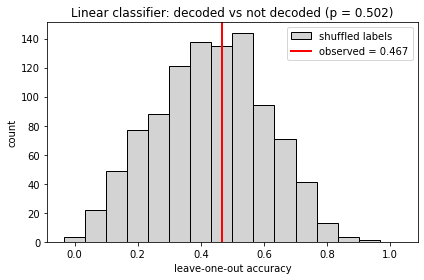

In [15]:
import matplotlib.pyplot as plt

null = np.array(null)
bins = np.arange(-0.5, 16.5) / 15          # one bin per possible accuracy (k/15)

plt.figure(figsize=(6, 4))
plt.hist(null, bins=bins, color='lightgrey', edgecolor='k', label='shuffled labels')
plt.axvline(acc, color='r', lw=2, label=f'observed = {acc:.3f}')
plt.xlabel('leave-one-out accuracy')
plt.ylabel('count')
plt.title(f'Linear classifier: decoded vs not decoded (p = {p:.3f})')
plt.legend()
plt.tight_layout()
plt.show()